# Copilot

In [1]:
from datetime import datetime

from bs4 import BeautifulSoup
import pandas as pd
import re
import numpy as np
from datetime import timedelta
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Correct data

In [2]:
df1 = pd.read_csv(f'data/autoscout/{datetime.now().strftime("%y.%m.%d")}_autoscout_raw.csv')
df1.isna().mean()

brand           0.000065
title           0.000065
description     0.012927
full_price      0.000000
mileage         0.005457
transmission    0.000000
year            0.000000
fuel            0.000000
cv              0.001429
location        0.000000
url             0.000000
dtype: float64

In [3]:
df1 = pd.read_csv(f'data/autoscout/{datetime.now().strftime("%y.%m.%d")}_autoscout_raw.csv')
# df1 = pd.read_csv(f'data/autoscout/24.05.14_autoscout_raw.csv')
df1['description'] = df1['title'] + ' ' + df1['description']
df1['location'] = df1['location'].str.extract(r'ES-\d+\s(.*)', expand=False)
df1['year'] = df1['year'].str.split('/').str[1]
df1['year'] = df1['year'].apply(lambda x: int(x) if x == x else np.nan)
df1 = df1.drop(['title', 'transmission'], axis=1)
df1['location'] = df1['location'].str.capitalize()
df1['brand'] = df1['brand'].str.capitalize()
df1

,brand,description,full_price,mileage,year,fuel,cv,location,url
0,Volkswagen,Volkswagen Käfer 1302,6000,85000.0,1972.0,Gasolina,50.0,Madrid,https://www.autoscout24.es/anuncios/volkswagen...
1,Volkswagen,Volkswagen Golf GTI 1.8 T Edición Especial 150,6000,209000.0,2000.0,Gasolina,150.0,Madrid,https://www.autoscout24.es/anuncios/volkswagen...
2,Fiat,Fiat Punto 1.3Mjt Easy 70kW,6000,186700.0,2017.0,Diésel,95.0,Torrejón de ardoz,https://www.autoscout24.es/anuncios/fiat-punto...
3,Seat,SEAT Leon León 1.4 TSI Sport-up,6000,190000.0,2008.0,Gasolina,125.0,Mostoles,https://www.autoscout24.es/anuncios/seat-leon-...
4,Hyundai,Hyundai i20 1.2,6000,28000.0,2009.0,Gasolina,77.0,Madrid,https://www.autoscout24.es/anuncios/hyundai-i2...
...,...,...,...,...,...,...,...,...,...
15389,Fiat,"Fiat Talento Fg. 1.6 Ecojet TT Base L 1,2 88kW",20900,139110.0,2018.0,Diésel,120.0,San sebastian de los reyes,https://www.autoscout24.es/anuncios/fiat-talen...
15390,Peugeot,Peugeot 3008 2.0BlueHDi GT LineS&S EAT8 180,20900,143000.0,2018.0,Diésel,181.0,Madrid,https://www.autoscout24.es/anuncios/peugeot-30...
15391,Bmw,BMW i3 94Ah BEV,20900,45000.0,2018.0,Eléctrico,170.0,Pinto,https://www.autoscout24.es/anuncios/bmw-i3-94a...
15392,Ford,Ford Transit Custom Van 2.0 TDCI 96KW 280 L1 T...,20900,123000.0,2021.0,Diésel,131.0,Coslada,https://www.autoscout24.es/anuncios/ford-trans...


In [4]:
df2 = pd.read_csv(f'data/flexicar/{datetime.now().strftime("%y.%m.%d")}_flexicar_raw.csv')
# df2 = pd.read_csv(f'data/flexicar/24.05.14_flexicar_raw.csv')
df2['cv'] = df2['description'].str.extract(r'\((\d+)CV\)', expand=False)
mask = pd.isna(df2['cv'])
df2['location'] = df2['city']
df2['location'] = df2['location'].str.capitalize()
df2.loc[mask, 'cv'] = df2.loc[mask, 'url'].str.extract(r'(\d+)(?:-cv|cv)(?!.*(?:-cv|cv))', expand=False)
df2['cv'] = df2['cv'].replace(np.nan, '0')
df2['cv'] = df2['cv'].astype(int)
df2['cv'] = df2['cv'].replace(0, np.nan)
df2['title'] = df2['title'].str.strip()
df2['description'] = df2['title'] + ' ' + df2['description']
df2['brand'] = df2['title'].str.split(' ').str[0]
df2['brand'] = df2['brand'].str.capitalize()
df2 = df2.drop(['title', 'discounted_price', 'monthly_rate', 'iva_deducible', 'offer', 'city', 'transmission'], axis=1)
df2

,full_price,description,year,mileage,fuel,url,cv,location,brand
0,NaN,Opel Corsa 1.3 CDTi Selective 75 CV,2016,160000,Diésel,https://www.flexicar.es//coches-ocasion/opel-c...,75.0,Getafe-fuenlabrada,Opel
1,7390.0,Citroen Berlingo BlueHDi 100,2015,83840,Diésel,https://www.flexicar.es//coches-ocasion/citroe...,NaN,Autosmadrid leganés,Citroen
2,7890.0,Dacia Sandero Ambiance 1.2 55kW (75CV) EU6,2016,111503,Gasolina,https://www.flexicar.es//coches-ocasion/dacia-...,75.0,San fernando,Dacia
3,NaN,Citroen C3 BlueHDi 55KW (75CV) S&S LIVE,2017,112826,Diésel,https://www.flexicar.es//coches-ocasion/citroe...,75.0,Autosmadrid alcalá de henares,Citroen
4,8490.0,Fiat 500 1.2 8v 69 CV Lounge,2015,88275,Gasolina,https://www.flexicar.es//coches-ocasion/fiat-5...,69.0,Autosmadrid leganés,Fiat
...,...,...,...,...,...,...,...,...,...
2004,NaN,BMW Serie 1 116d EfficientDynamics,2016,85840,Diésel,https://www.flexicar.es//coches-ocasion/bmw-se...,NaN,Autosmadrid leganés,Bmw
2005,20490.0,Renault Trafic Furgón 27 L1H1 Energy BluedCi 1...,2020,59557,Diésel,https://www.flexicar.es//coches-ocasion/renaul...,NaN,Autosmadrid alcorcon,Renault
2006,21790.0,Peugeot 2008 GT BlueHDI 130 S&S EAT8,2020,55200,Diésel,https://www.flexicar.es//coches-ocasion/peugeo...,NaN,Coslada,Peugeot
2007,21990.0,Toyota C-HR 1.8 125H Advance,2019,50724,Híbrido,https://www.flexicar.es//coches-ocasion/toyota...,NaN,Autosmadrid san sebastián de los reyes,Toyota


In [5]:
df3 = pd.read_csv(f'data/ocasion/{datetime.now().strftime("%y.%m.%d")}_ocasion_raw.csv')
# df3 = pd.read_csv(f'data/ocasion/24.05.14_ocasion_raw.csv')
df3 = df3.loc[df3['status'] == 'Available']
df2['location'] = df2['location'].str.capitalize()
df3['description'] = df3['title'] + ' ' + df3['description']
df3['brand'] = df3['title'].str.split(' ').str[0]
df3['brand'] = df3['brand'].str.capitalize()
df3 = df3.drop(['title', 'discounted_price', 'discount', 'status', 'district', 'libro', 'warranty', 'owner', 'vista', 'transmission'], axis=1)
df3

,full_price,description,year,mileage,fuel,cv,location,url,brand
0,5300.0,Mercedes Clase B Mercedes-Benz 200 CDI (140 CV),2006,128208,Diésel,140,Madrid,https://www.ocasionplus.com/coches-segunda-man...,Mercedes
1,NaN,SsangYong Rexton 270 Xdi Full (165 CV),2005,156797,Diésel,165,Madrid,https://www.ocasionplus.com/coches-segunda-man...,Ssangyong
2,5900.0,Fiat 500 1.2 Pop (69 CV),2012,161959,Gasolina,69,Madrid,https://www.ocasionplus.com/coches-segunda-man...,Fiat
3,5900.0,Ford Mondeo 2.0 TDCI Trend X Powershift (140 CV),2010,170036,Diésel,140,Madrid,https://www.ocasionplus.com/coches-segunda-man...,Ford
4,5900.0,Mercedes Clase E Mercedes-Benz 240 Elegance (1...,2002,148000,Gasolina,177,Madrid,https://www.ocasionplus.com/coches-segunda-man...,Mercedes
...,...,...,...,...,...,...,...,...,...
780,21990.0,BMW Serie 3 318d Gran Turismo (150 CV) Pack M,2016,102778,Diésel,150,Madrid,https://www.ocasionplus.com/coches-segunda-man...,Bmw
781,22990.0,Opel Combo Life 1.5 TD S&S Selective L (131 CV),2019,60496,Diésel,131,Madrid,https://www.ocasionplus.com/coches-segunda-man...,Opel
782,22590.0,Volkswagen Sharan Edition 2.0 TDI BMT (150 CV)...,2016,130377,Diésel,150,Madrid,https://www.ocasionplus.com/coches-segunda-man...,Volkswagen
783,21990.0,Renault Mégane TCe GPF 117 kW (160 CV),2019,48188,Gasolina,160,Madrid,https://www.ocasionplus.com/coches-segunda-man...,Renault


In [6]:
df4 = pd.read_csv(f'data/autocasion/{datetime.now().strftime("%y.%m.%d")}_autocasion_raw.csv')
# df4 = pd.read_csv(f'data/ocasion/24.05.14_ocasion_raw.csv')
df4['title'] = df4['title'].str.strip()
df4['description'] = df4['title']
df4['brand'] = df4['title'].str.split(' ').str[0]
df4['brand'] = df4['brand'].str.capitalize()
df4 = df4.drop(['title'], axis=1)
df4

,full_price,year,mileage,fuel,location,url,cv,description,brand
0,5000,2005,248000,Diésel,Madrid,https://www.autocasion.com/coches-segunda-mano...,180.0,AUDI A6 Avant 2.5TDI quattro Tiptronic,Audi
1,5000,2005,131000,Gasolina,Madrid,https://www.autocasion.com/coches-segunda-mano...,255.0,AUDI A6 3.2 FSI quattro,Audi
2,5000,2007,124519,Gasolina,Madrid,https://www.autocasion.com/coches-segunda-mano...,105.0,ALFA ROMEO 147 1.6 TS Selective,Alfa
3,5000,2009,108000,Diésel,Madrid,https://www.autocasion.com/coches-segunda-mano...,90.0,PEUGEOT 207 1.6HDI Sport,Peugeot
4,5000,2007,143000,Diésel,Madrid,https://www.autocasion.com/coches-segunda-mano...,130.0,RENAULT Laguna 1.9DCI Dynamique 130,Renault
...,...,...,...,...,...,...,...,...,...
20181,19900,2021,34387,Gasolina,Madrid,https://www.autocasion.com/coches-segunda-mano...,140.0,RENAULT Captur TCe GPF Micro Híbrido Intens 103kW,Renault
20182,19900,2016,138900,Gasolina,Madrid,https://www.autocasion.com/coches-segunda-mano...,190.0,AUDI A4 2.0 TFSI ultra Design ed. S tronic 140kW,Audi
20183,19900,2020,79951,Diésel,Madrid,https://www.autocasion.com/coches-segunda-mano...,120.0,VOLKSWAGEN Passat 1.6TDI Executive DSG7,Volkswagen
20184,19900,2019,63200,Gasolina,Madrid,https://www.autocasion.com/coches-segunda-mano...,130.0,VOLKSWAGEN Golf 1.5 TSI Evo BM Advance DSG7 96kW,Volkswagen


In [7]:
df2 = df2[df1.columns]
df3 = df3[df1.columns]
df4 = df4[df1.columns]
df = pd.concat([df1,df2,df3,df4], ignore_index=True)
df['location'] = df['location'].str.lower().str.strip()
df = df.drop_duplicates()
df = df.dropna(subset=['full_price', 'cv'])
df['age'] = 2024 - df['year']
df = df.drop(['year'], axis=1)

average_mileage_df = df.groupby('age')['mileage'].mean().reset_index()
average_mileage_df.columns = ['age', 'average_mileage']

average_price_df = df.groupby('age')['full_price'].mean().reset_index()
average_price_df.columns = ['age', 'average_price']

by_year_df = pd.merge(average_mileage_df, average_price_df, on='age')

df = pd.merge(df, average_mileage_df, on='age', how='left')
df['delta_mileage'] = df['mileage'] - df['average_mileage']

# df = df[df['full_price'] <= 15000]
df.drop_duplicates(subset=['brand', 'description', 'full_price', 'mileage', 'fuel', 'cv', 'age'], inplace=True)
df = df.reindex(columns=['fuel', 'brand', 'description', 'location', 'url', 'full_price', 'mileage', 'cv','average_mileage', 'age'])


In [8]:
by_year_df['%'] = by_year_df['average_price']/17796.899522
by_year_df

,age,average_mileage,average_price,%
0,0.0,1487.507177,17796.899522,1.000000
1,1.0,14997.925457,17093.357243,0.960468
2,2.0,42414.808955,16839.038806,0.946178
3,3.0,66839.247016,16244.517050,0.912772
4,4.0,76279.466879,15845.038132,0.890326
5,5.0,85289.236545,15155.989998,0.851608
6,6.0,92857.075411,14515.688528,0.815630
7,7.0,101127.285104,14219.546093,0.798990
8,8.0,110876.036120,13438.783279,0.755119
9,9.0,117927.105495,13076.513187,0.734764


In [9]:
columns = ['full_price', 'mileage', 'cv', 'age']
for col in columns:
    mean = df[col].mean()
    std = df[col].std()
    
    # Define the upper and lower bounds
    lower_bound = mean - 3*std
    upper_bound = mean + 3*std
    
    # Filter the DataFrame
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
df.to_csv(f'data/assembled/{datetime.now().strftime("%y.%m.%d")}_assembled.csv', index=False)

In [17]:
df['price_norm'] = -(df['full_price']-df['full_price'].mean())/(df['full_price'].std())
df['mileage_norm'] = -(df['mileage']-df['mileage'].mean())/(df['mileage'].std())
df['cv_norm'] = (df['cv']-df['cv'].mean())/(df['cv'].std())
df['age_norm'] = -(df['age']-df['age'].mean())/(df['age'].std())

df['rating'] = df['price_norm'] + df['mileage_norm'] + df['cv_norm'] + df['age_norm']

In [23]:
pd.set_option('display.max_colwidth', None)
df.sort_values(by='rating', ascending=False).head(30)
df.drop


,fuel,brand,description,location,url,full_price,mileage,cv,average_mileage,age,price_norm,mileage_norm,cv_norm,age_norm,rating
5986,Eléctrico,Nissan,Nissan Leaf 40 kWh Acenta,madrid,https://www.autoscout24.es/anuncios/nissan-leaf-40-kwh-acenta-electrico-blanco-2c8525c8-e03c-4551-9a55-414c07e9ae1d,13490.0,31699.0,218.0,85289.236545,5.0,0.348586,1.131214,3.234485,0.271126,4.985411
5826,Eléctrico,Nissan,Nissan Leaf 40 kWh Acenta,madrid,https://www.autoscout24.es/anuncios/nissan-leaf-40-kwh-acenta-electrico-blanco-03ba61fc-a2a2-463e-837b-e32778dc738a,13390.0,34145.0,218.0,85289.236545,5.0,0.376724,1.081139,3.234485,0.271126,4.963474
5727,Eléctrico,Nissan,Nissan Leaf 40 kWh Acenta,madrid,https://www.autoscout24.es/anuncios/nissan-leaf-40-kwh-acenta-electrico-blanco-ef7fa102-d8b2-437d-8ffa-13d49aea6229,13290.0,36770.0,218.0,85289.236545,5.0,0.404862,1.027399,3.234485,0.271126,4.937872
5524,Eléctrico,Nissan,Nissan Leaf 40 kWh Acenta,madrid,https://www.autoscout24.es/anuncios/nissan-leaf-40-kwh-acenta-electrico-blanco-6dbeae82-05ea-4f2d-bf18-c71b41b970c8,12990.0,43781.0,218.0,85289.236545,5.0,0.489277,0.883867,3.234485,0.271126,4.878755
27424,Eléctrico,Nissan,NISSAN Leaf 40 kWh Acenta,madrid,https://www.autocasion.com/coches-segunda-mano/nissan-leaf-ocasion/leaf-40-kwh-acenta-ref12294804,15490.0,23560.0,218.0,85289.236545,5.0,-0.214179,1.297839,3.234485,0.271126,4.589271
21592,Diésel,Volkswagen,VOLKSWAGEN Golf 2.0TDI Style DSG 110kW,madrid,https://www.autocasion.com/coches-segunda-mano/volkswagen-golf-ocasion/golf-2-0tdi-style-dsg-110kw-ref13272152,12250.0,24000.0,150.0,14997.925457,1.0,0.697500,1.288832,1.018380,1.561356,4.566068
4323,Diésel,Volkswagen,Volkswagen Golf 2.0TDI Style DSG 110kW,madrid,https://www.autoscout24.es/anuncios/volkswagen-golf-2-0tdi-style-dsg-110kw-diesel-azul-e37ba200-2e8b-4332-9853-15ae721e674c,12250.0,24000.0,150.0,14997.925457,1.0,0.697500,1.288832,1.018380,1.561356,4.566068
26668,Eléctrico,Nissan,NISSAN Leaf 40 kWh Acenta,madrid,https://www.autocasion.com/coches-segunda-mano/nissan-leaf-ocasion/leaf-40-kwh-acenta-ref12342335,14990.0,31699.0,218.0,85289.236545,5.0,-0.073488,1.131214,3.234485,0.271126,4.563337
25943,Eléctrico,Nissan,NISSAN Leaf 40 kWh Acenta,madrid,https://www.autocasion.com/coches-segunda-mano/nissan-leaf-ocasion/leaf-40-kwh-acenta-ref12342339,14890.0,34145.0,218.0,85289.236545,5.0,-0.045350,1.081139,3.234485,0.271126,4.541400
11605,Diésel,Bmw,BMW X6 xDrive 40dA,madrid,https://www.autoscout24.es/anuncios/bmw-x6-xdrive-40da-diesel-blanco-34bf7dba-c330-4837-a44f-797409d0c17b,17800.0,25000.0,306.0,156526.106061,12.0,-0.864173,1.268359,6.102386,-1.986778,4.519794


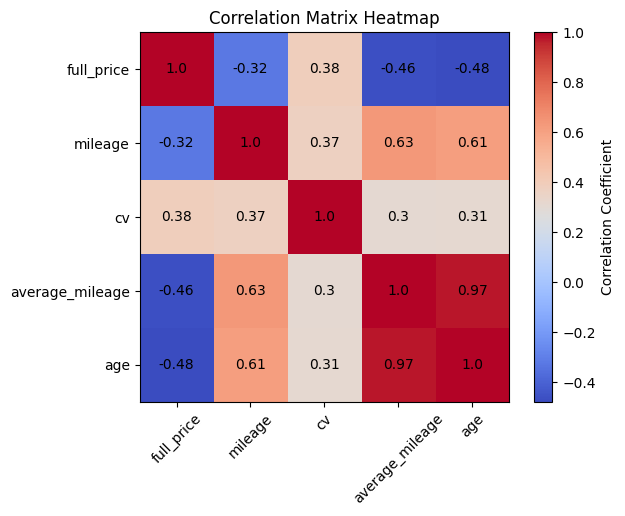

In [10]:
import numpy as np

spearman_matrix = df.drop(['brand', 'url', 'description', 'fuel', 'location'], axis=1).corr(method='spearman')
correlation_matrix = df.drop(['brand', 'url', 'description', 'fuel', 'location'], axis=1).corr()

plt.imshow(correlation_matrix, cmap='coolwarm')  # Adjust 'coolwarm' for preferred colormap

# Add labels and title
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(spearman_matrix.columns)), spearman_matrix.columns, rotation=45)
plt.yticks(range(len(spearman_matrix.columns)), spearman_matrix.columns)
plt.title('Correlation Matrix Heatmap')

# Add correlation numbers
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        text = plt.text(j, i, np.around(correlation_matrix.iloc[i, j], decimals=2),
                       ha="center", va="center", color="black")

# Display the plot
plt.show()
